In [1]:
import pydpeet as eet
import matplotlib.pyplot as plt
eet.utils.set_logging_style("WARNING")

OCVs are Importend for Analyzing Materials, Ageeing and for Parametrisiation of Models. Here the Funtion from [Squences](Tutorial_02_Sequence.ipynb) is used to automatically extract incremntall OCVs from Lab-Data and analyze it through DVA and ICA

In [2]:
Data = eet.convert.convert_file(config = 'Neware', input_path = r"..\..\res\raw\Cal_Ageing_Checkup1.xlsx")

D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\convert\zyklisierer\neware\reader.py:281: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_auxvol.rename(columns={'Date': 'Date - auxVol', 'DataPoint': 'DataPoint - auxVol'}, inplace=True)
D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\convert\zyklisierer\neware\reader.py:287: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_auxtemp.rename(columns={'Date': 'Date - auxTemp', 'DataPoint': 'DataPoint - auxTemp'}, inplace=True)
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\convert\map.py:47 | Missing column: 'EISFreq[Hz]'. Adding Collumn (wit

In [3]:
OCVs = eet.process.analyze.iocv_detection(df = Data, visualize = False)

WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\sequence\step_analyzer.py:166 | Dropping NaN values in 'Testtime[s]', dropping duplicates and sorting 'Testtime[s]' column.
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\sequence\utils\processing\widen_constant_segments.py:157 | Removed segments during finetuning of the width in 'Segment_Current[A]': 11:9111, 43678:44495 ...
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\sequence\utils\processing\widen_constant_segments.py:159 | Removed segments during finetuning of the width in 'Segment_Power[W]': 5:10
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\sequence\utils\processing\check_CV_results.py:208 | Suspicious Voltage Segments that end with Current[A] = 0.0 found.
WARNING | D:\Coding\PyDPEET_BA\pythonProject\pydpeet\src\pydpeet\process\sequence\utils\processing\check_CV_results.py:214 | Turned into CC segments: [(np.int64(1), (11522.9,

In [4]:
OCVs[0].head()

,Testtime[s],Voltage[V],Current[A],Power[W],ID,Power[W],Metadata,StepID,Temperature[°C],Absolute Time[yyyy-mm-dd hh:mm:ss],...,Variable,Duration,Length,Min,Max,Avg,Type,Direction,Slope,iOCV_type
44500.0,44494.5,4.1932,0.0,0.0,9,0.0,None,5.0,25.2,2024-02-01 22:30:38,...,I,900.0,899.0,0.0,0.0,0.0,Rest,Neutral,0.0,Discharge
45008.0,45000.0,4.1681,0.0,0.0,11,0.0,None,7.0,25.2,2024-02-01 22:39:04,...,I,360.0,359.0,0.0,0.0,0.0,Rest,Neutral,0.0,Discharge
45516.0,45505.5,4.1495,0.0,0.0,13,0.0,None,9.0,25.2,2024-02-01 22:47:29,...,I,360.0,359.0,0.0,0.0,0.0,Rest,Neutral,0.0,Discharge
46024.0,46011.0,4.1356,0.0,0.0,15,0.0,None,11.0,25.3,2024-02-01 22:55:55,...,I,360.0,359.0,0.0,0.0,0.0,Rest,Neutral,0.0,Discharge
46532.0,46516.5,4.1246,0.0,0.0,17,0.0,None,13.0,25.1,2024-02-01 23:04:21,...,I,360.0,359.0,0.0,0.0,0.0,Rest,Neutral,0.0,Discharge


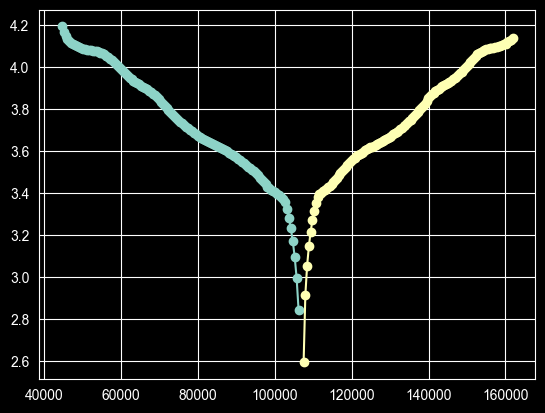

In [5]:
fig, ax = plt.subplots()

for OCV in OCVs:
    ax.plot(OCV['Testtime[s]'], OCV['Voltage[V]'], marker='o', linestyle='-', label='iOCV Points')

In [6]:
# Fake SOC

for idx in enumerate(OCVs):
    OCV = OCVs[idx[0]]
    OCV['Fake SOC'] = (OCV['Testtime[s]'] - OCV['Testtime[s]'].min()) / (OCV['Testtime[s]'].max() - OCV['Testtime[s]'].min())
    OCV['Fake SOC'] = OCV.sort_values(by='Voltage[V]', ascending=False)['Fake SOC'].values
    OCVs[idx[0]] = OCV

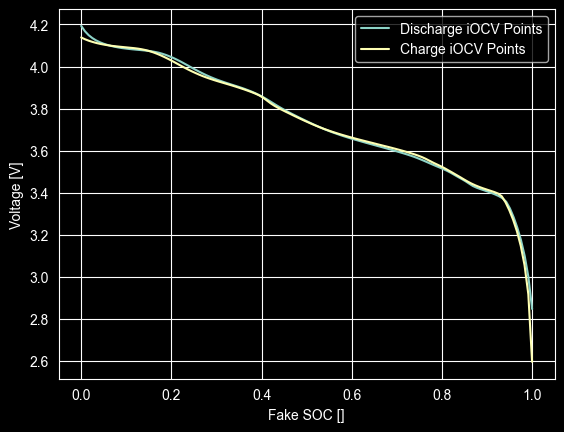

In [7]:
fig, ax = plt.subplots()

for OCV in OCVs:
    ax.plot(OCV['Fake SOC'], OCV['Voltage[V]'], linestyle='-', label=f'{OCV['iOCV_type'].iloc[0]} iOCV Points')
    ax.legend()
    ax.set_ylabel('Voltage [V]')
    ax.set_xlabel('Fake SOC []')